# GMFlow Posterior Re-derivation: Schedule-Agnostic Form

Re-derives `gmflow_posterior_mean_jit` keeping `(alpha_t, sigma_t)` as free parameters.  
Current code hardcodes `alpha = 1 - sigma` (linear/VE). Goal: work for any noise schedule,  
including trig/VP (`alpha = cos(πt/2)`, `sigma = sin(πt/2)`).

**Source:** `repos/piFlow/lakonlab/models/diffusions/gmflow.py`, lines 44–72

## Section 1 — Symbol Setup

In [1]:
from sympy import *

# Schedule parameters — free positive reals, NO relationship imposed between them
alpha_t, sigma_t = symbols('alpha_t sigma_t', positive=True)
alpha_s, sigma_s = symbols('alpha_s sigma_s', positive=True)

# Observation variables
x_t, x_s = symbols('x_t x_s', real=True)

# GM component parameters (scalar stand-ins; channel sum handled separately)
mu_k, var_k = symbols('mu_k var_k', real=True, positive=True)

# Confirm no schedule relationship
print('Symbols defined. No alpha = f(sigma) relationship imposed.')
print('alpha_t, sigma_t:', alpha_t, sigma_t)
print('alpha_s, sigma_s:', alpha_s, sigma_s)

Symbols defined. No alpha = f(sigma) relationship imposed.
alpha_t, sigma_t: alpha_t sigma_t
alpha_s, sigma_s: alpha_s sigma_s


## Section 2 — Likelihood in Information Form

Forward process: $x_t = \alpha_t x_0 + \sigma_t \varepsilon$, so

$$p(x_t \mid x_0) = \mathcal{N}(\alpha_t x_0,\; \sigma_t^2)$$

In **information (canonical) form** $\mathcal{N}^{-1}(\eta, \Lambda)$ where $\Lambda$ is precision and $\eta$ is the information vector:

$$\Lambda_t = \frac{\alpha_t^2}{\sigma_t^2}, \qquad \eta_t = \frac{\alpha_t}{\sigma_t^2} x_t$$

In [2]:
# Precision (scalar) and information vector for the t-observation
Lambda_t = alpha_t**2 / sigma_t**2
eta_t    = alpha_t * x_t / sigma_t**2

# Same for the source observation s
Lambda_s = alpha_s**2 / sigma_s**2
eta_s    = alpha_s * x_s / sigma_s**2

print('Precision (t):', Lambda_t)
print('Info vector (t):', eta_t)
print()
print('Precision (s):', Lambda_s)
print('Info vector (s):', eta_s)

Precision (t): alpha_t**2/sigma_t**2
Info vector (t): alpha_t*x_t/sigma_t**2

Precision (s): alpha_s**2/sigma_s**2
Info vector (s): alpha_s*x_s/sigma_s**2


## Section 3 — Posterior Update (core derivation)

**Setup:**  
- GM prior from source observation: $p(x_0 \mid x_s) = \sum_k w_k \mathcal{N}(\mu_k, \mathrm{var}_k)$
- New observation: $p(x_t \mid x_0) = \mathcal{N}(\alpha_t x_0, \sigma_t^2)$
- Goal: update $p(x_0 \mid x_s)$ to $p(x_0 \mid x_t)$ using x_t as a better (less noisy) observation

> **Domain constraint:** formula valid only for $t < s$, i.e. $\sigma_t < \sigma_s$ (x_t less noisy than x_s).

The update is an **importance reweighting** step:

$$p(x_0 \mid x_t) \;\propto\; \frac{p(x_t \mid x_0)}{p(x_s \mid x_0)} \cdot p(x_0 \mid x_s)$$

In information (canonical) form, dividing two Gaussians *subtracts* their precisions and information vectors.  
The **gain** (information added by replacing x_s with x_t):

$$\zeta = \Lambda_t - \Lambda_s = \left(\frac{\alpha_t}{\sigma_t}\right)^2 - \left(\frac{\alpha_s}{\sigma_s}\right)^2 \;>\; 0 \quad (\text{since } t < s)$$

$$\nu = \eta_t - \eta_s = \frac{\alpha_t x_t}{\sigma_t^2} - \frac{\alpha_s x_s}{\sigma_s^2}$$

In [3]:
# Precision gain and information vector gain
zeta = Lambda_t - Lambda_s
nu   = eta_t   - eta_s

zeta_simplified = simplify(zeta)
nu_simplified   = simplify(nu)

print('zeta =', zeta_simplified)
print('nu   =', nu_simplified)

zeta = -alpha_s**2/sigma_s**2 + alpha_t**2/sigma_t**2
nu   = -alpha_s*x_s/sigma_s**2 + alpha_t*x_t/sigma_t**2


### Per-component posterior

For component $k$ with prior $\mathcal{N}(\mu_k, \mathrm{var}_k)$:

- Updated precision: $\Lambda_k^{\text{post}} = 1/\mathrm{var}_k + \zeta$
- Updated variance: $\mathrm{var}_k^{\text{post}} = 1 / \Lambda_k^{\text{post}} = \mathrm{var}_k / (\mathrm{var}_k \zeta + 1)$
- Denominator: $d_k = \mathrm{var}_k \zeta + 1$
- Updated mean: $\mu_k^{\text{post}} = \mathrm{var}_k^{\text{post}} \cdot (\eta_k^{\text{prior}} + \nu) = \dfrac{\mathrm{var}_k \nu + \mu_k}{d_k}$
- Log-weight delta: $\Delta \log w_k = \dfrac{\mu_k^T (\nu - \tfrac{1}{2}\zeta\,\mu_k)}{d_k}$ (from completing the square)

> **Assumption — shared variance across components:**  
> The full completing-the-square log-normalizer is  
> $\dfrac{\mu_k^T(\nu - \frac{1}{2}\zeta\mu_k)}{d_k} + \dfrac{\|\nu\|^2\,\mathrm{var}_k}{2\,d_k}$  
> The second term $\|\nu\|^2\mathrm{var}_k/(2d_k)$ is dropped here because in the piflow implementation
> `gm_vars` has a singleton K-dimension (shape `(B,1,1,...)`), so $\mathrm{var}_k$ and $d_k$ are
> identical across all components. The dropped term is then k-independent and cancels inside `softmax`.  
> **If per-component variances are introduced, both terms must be included.** See Section 9.

In [4]:
# Denominator
denom_k = var_k * zeta + 1

# Posterior mean for component k
out_mean_k = (var_k * nu + mu_k) / denom_k

# Log-weight delta (scalar; in practice summed over channel dim)
logweight_delta_k = mu_k * (nu - Rational(1,2) * zeta * mu_k) / denom_k

print('denom_k           =', simplify(denom_k))
print('out_mean_k        =', simplify(out_mean_k))
print('logweight_delta_k =', simplify(logweight_delta_k))

denom_k           = -alpha_s**2*var_k/sigma_s**2 + alpha_t**2*var_k/sigma_t**2 + 1
out_mean_k        = (-mu_k*sigma_s**2*sigma_t**2 + var_k*(alpha_s*sigma_t**2*x_s - alpha_t*sigma_s**2*x_t))/(-sigma_s**2*sigma_t**2 + var_k*(alpha_s**2*sigma_t**2 - alpha_t**2*sigma_s**2))
logweight_delta_k = mu_k*(2*alpha_s*sigma_t**2*x_s - 2*alpha_t*sigma_s**2*x_t - mu_k*(alpha_s**2*sigma_t**2 - alpha_t**2*sigma_s**2))/(2*(-sigma_s**2*sigma_t**2 + var_k*(alpha_s**2*sigma_t**2 - alpha_t**2*sigma_s**2)))


### Display as LaTeX

In [5]:
print('zeta:              ', latex(zeta_simplified))
print('nu:                ', latex(nu_simplified))
print('denom_k:           ', latex(simplify(denom_k)))
print('out_mean_k:        ', latex(simplify(out_mean_k)))
print('logweight_delta_k: ', latex(simplify(logweight_delta_k)))

zeta:               - \frac{\alpha_{s}^{2}}{\sigma_{s}^{2}} + \frac{\alpha_{t}^{2}}{\sigma_{t}^{2}}
nu:                 - \frac{\alpha_{s} x_{s}}{\sigma_{s}^{2}} + \frac{\alpha_{t} x_{t}}{\sigma_{t}^{2}}
denom_k:            - \frac{\alpha_{s}^{2} var_{k}}{\sigma_{s}^{2}} + \frac{\alpha_{t}^{2} var_{k}}{\sigma_{t}^{2}} + 1
out_mean_k:         \frac{- \mu_{k} \sigma_{s}^{2} \sigma_{t}^{2} + var_{k} \left(\alpha_{s} \sigma_{t}^{2} x_{s} - \alpha_{t} \sigma_{s}^{2} x_{t}\right)}{- \sigma_{s}^{2} \sigma_{t}^{2} + var_{k} \left(\alpha_{s}^{2} \sigma_{t}^{2} - \alpha_{t}^{2} \sigma_{s}^{2}\right)}
logweight_delta_k:  \frac{\mu_{k} \left(2 \alpha_{s} \sigma_{t}^{2} x_{s} - 2 \alpha_{t} \sigma_{s}^{2} x_{t} - \mu_{k} \left(\alpha_{s}^{2} \sigma_{t}^{2} - \alpha_{t}^{2} \sigma_{s}^{2}\right)\right)}{2 \left(- \sigma_{s}^{2} \sigma_{t}^{2} + var_{k} \left(\alpha_{s}^{2} \sigma_{t}^{2} - \alpha_{t}^{2} \sigma_{s}^{2}\right)\right)}


## Section 4 — Verification: Linear Schedule Reduces to Existing Code

Substitute `alpha = 1 - sigma` and confirm match with `gmflow_posterior_mean_jit` (lines 54–67).

In [6]:
# Substitute linear schedule into general formulas
linear_subs = {
    alpha_t: 1 - sigma_t,
    alpha_s: 1 - sigma_s,
}

zeta_lin = simplify(zeta.subs(linear_subs))
nu_lin   = simplify(nu.subs(linear_subs))
denom_lin = simplify(denom_k.subs(linear_subs))
mean_lin  = simplify(out_mean_k.subs(linear_subs))

print('=== Linear schedule ===')
print('zeta  =', zeta_lin)
print('nu    =', nu_lin)
print('denom =', denom_lin)
print('mean  =', mean_lin)
print()

# Cross-check: existing code computes
#   alpha_over_sigma_t = (1 - sigma_t) / sigma_t
#   zeta = alpha_over_sigma_t**2 - alpha_over_sigma_s**2
#   nu   = alpha_over_sigma_t * x_t / sigma_t - alpha_over_sigma_s * x_s / sigma_s
alpha_over_sigma_t = (1 - sigma_t) / sigma_t
alpha_over_sigma_s = (1 - sigma_s) / sigma_s
zeta_code = alpha_over_sigma_t**2 - alpha_over_sigma_s**2
nu_code   = alpha_over_sigma_t * x_t / sigma_t - alpha_over_sigma_s * x_s / sigma_s

diff_zeta = simplify(zeta_lin - zeta_code)
diff_nu   = simplify(nu_lin   - nu_code)

print('zeta match (should be 0):', diff_zeta)
print('nu   match (should be 0):', diff_nu)

=== Linear schedule ===
zeta  = (sigma_t - 1)**2/sigma_t**2 - (sigma_s - 1)**2/sigma_s**2
nu    = -x_t/sigma_t + x_t/sigma_t**2 + x_s/sigma_s - x_s/sigma_s**2
denom = 1 + var_k*(sigma_t - 1)**2/sigma_t**2 - var_k*(sigma_s - 1)**2/sigma_s**2
mean  = (mu_k*sigma_s**2*sigma_t**2 - var_k*(sigma_s**2*x_t*(sigma_t - 1) - sigma_t**2*x_s*(sigma_s - 1)))/(sigma_s**2*sigma_t**2 + var_k*(sigma_s**2*(sigma_t - 1)**2 - sigma_t**2*(sigma_s - 1)**2))



zeta match (should be 0):

 0
nu   match (should be 0): 0


## Section 5 — Verification: Trig Schedule (VP / TrigFlow)

Substitute `alpha = cos(πt/2)`, `sigma = sin(πt/2)`. Check limits.

In [7]:
t, s = symbols('t s', positive=True)

trig_subs = {
    alpha_t: cos(pi*t/2),
    sigma_t: sin(pi*t/2),
    alpha_s: cos(pi*s/2),
    sigma_s: sin(pi*s/2),
}

zeta_trig = trigsimp(zeta.subs(trig_subs))
nu_trig   = trigsimp(nu.subs(trig_subs))

print('=== Trig (VP) schedule ===')
print('zeta =', zeta_trig)
print('nu   =', nu_trig)
print()

# Check: VP identity alpha^2 + sigma^2 = 1
vp_identity = simplify(cos(pi*t/2)**2 + sin(pi*t/2)**2 - 1)
print('VP identity (cos²+sin²-1, should be 0):', vp_identity)

=== Trig (VP) schedule ===
zeta = 2*cos(pi*t/2)**2/(1 - cos(pi*t)) - 2*cos(pi*s/2)**2/(1 - cos(pi*s))
nu   = -2*x_s*cos(pi*s/2)/(1 - cos(pi*s)) + 2*x_t*cos(pi*t/2)/(1 - cos(pi*t))

VP identity (cos²+sin²-1, should be 0): 0


In [8]:
# Boundary limits of out_mean_k under trig schedule
# t -> 0: x_t becomes noiseless (sigma_t -> 0, Lambda_t -> inf), posterior collapses to x_t
# t -> 1: OUTSIDE VALID DOMAIN (t=1 > s=0.5, violates t < s constraint).
#         At t=1: alpha_t=0, Lambda_t=0, so gain zeta = -Lambda_s < 0.
#         Formula is algebraically defined but unphysical; result is NOT mu_k.

mean_trig = out_mean_k.subs(trig_subs)

# t -> 0 limit (s fixed at 0.5): expect x_t
lim_t0 = limit(mean_trig.subs(s, Rational(1,2)), t, 0, '+')
print('limit t->0 (s=0.5):', simplify(lim_t0))   # should print x_t

# t -> 1 limit (s=0.5): t > s, unphysical — shown for completeness only
# Result depends on x_s and var_k because zeta < 0 at t=1
lim_t1 = limit(mean_trig.subs(s, Rational(1,2)), t, 1, '-')
print('limit t->1 (s=0.5) [UNPHYSICAL — outside t<s domain]:', simplify(lim_t1))

limit t->0 (s=0.5): x_t
limit t->1 (s=0.5) [UNPHYSICAL — outside t<s domain]: (-mu_k + sqrt(2)*var_k*x_s)/(var_k - 1)


## Section 6 — Numerical Verification (PyTorch)

3-way comparison:
- **(a)** General formula with `alpha = 1 - sigma` → must match existing `gmflow_posterior_mean_jit`
- **(b)** General formula with trig schedule → must match brute-force (adaptive grid)
- **(c)** Brute-force: evaluate GM log-pdf at grid of x0 values, weight by likelihood, take weighted mean

In [9]:
import torch
import math

torch.manual_seed(42)
B, K, C = 2, 4, 8   # batch, components, channels

def posterior_general(alpha_t, sigma_t, alpha_s, sigma_s, x_t, x_s,
                      gm_means, gm_vars, gm_logweights, eps=1e-6):
    """Schedule-agnostic posterior mean.

    gm_dim and channel_dim are inferred from gm_means.dim() so the function
    works for both simplified 3-D test tensors (B, K, C) and full image
    tensors (B, K, C, H, W) — matching gmflow_posterior_mean_jit's convention
    where K is always the second dimension (dim 1 = dim -(ndim-1)).

    **Requires t < s** (sigma_t < sigma_s): x_t must be less noisy than x_s.

    **Requires shared var_k across components**: gm_vars must have a singleton
    K-dimension (e.g. shape (B,1,1) or (B,1,1,H,W)). Per-component variances
    require an additional nu^2*var/(2*d) term in the log-weight; see Section 9.

    Shape contract:
      alpha_t, sigma_t: broadcastable with x_t  (e.g. (B,1) for 2-D x_t)
      x_t, x_s:        (B, C) or (B, C, H, W)
      gm_means:         (B, K, C) or (B, K, C, H, W)
      gm_vars:          (B, 1, 1) or (B, 1, 1, H, W)   [K and C singletons]
      gm_logweights:    (B, K, 1) or (B, K, 1, H, W)
    """
    sigma_t = sigma_t.clamp(min=eps)
    sigma_s = sigma_s.clamp(min=eps)

    if (sigma_t >= sigma_s).any():
        raise ValueError(
            "posterior_general requires t < s (sigma_t < sigma_s). "
            f"Got sigma_t max={sigma_t.max().item():.4f} >= sigma_s min={sigma_s.min().item():.4f}. "
            "x_t must be less noisy than x_s."
        )

    # zeta/nu: same spatial shape as x_t  (B, C) or (B, C, H, W)
    zeta = (alpha_t / sigma_t).square() - (alpha_s / sigma_s).square()
    nu   = alpha_t * x_t / sigma_t**2   - alpha_s * x_s / sigma_s**2

    # Clamp zeta — derived in Sec 7: float32_max / max_var_k (conservative upper bound 10.0)
    ZETA_MAX = torch.finfo(torch.float32).max / 10.0  # derived in Sec 7: float32_max / max_var_k
    zeta = zeta.clamp(max=ZETA_MAX)

    # K-dimension (gm_dim) is always dim 1 = dim -(ndim-1) of gm_means.
    # C-dimension (channel_dim) is the next one inward: dim -(ndim-2).
    gm_dim      = 1 - gm_means.dim()   # -2 for 3-D, -4 for 5-D
    channel_dim = 2 - gm_means.dim()   # -1 for 3-D, -3 for 5-D

    nu   = nu.unsqueeze(gm_dim)
    zeta = zeta.unsqueeze(gm_dim)
    denom = (gm_vars * zeta + 1).clamp(min=eps)

    out_means  = (gm_vars * nu + gm_means) / denom
    logw_delta = (gm_means * (nu - 0.5 * zeta * gm_means)).sum(
        dim=channel_dim, keepdim=True) / denom
    out_weights = (gm_logweights + logw_delta).softmax(dim=gm_dim)

    return (out_means * out_weights).sum(dim=gm_dim)


def gmflow_posterior_mean_jit_ref(sigma_t_src, sigma_t, x_t_src, x_t,
                                   gm_means, gm_vars, gm_logweights, eps=1e-6):
    """Reference: existing hardcoded linear code (alpha = 1 - sigma).

    Uses the same dynamic gm_dim / channel_dim fix for consistency.
    """
    sigma_t_src = sigma_t_src.clamp(min=eps)
    sigma_t     = sigma_t.clamp(min=eps)
    alpha_t_src = 1 - sigma_t_src
    alpha_t     = 1 - sigma_t
    aos_src = alpha_t_src / sigma_t_src
    aos_t   = alpha_t     / sigma_t
    zeta = aos_t.square() - aos_src.square()
    nu   = aos_t * x_t / sigma_t - aos_src * x_t_src / sigma_t_src

    gm_dim      = 1 - gm_means.dim()
    channel_dim = 2 - gm_means.dim()

    nu   = nu.unsqueeze(gm_dim)
    zeta = zeta.unsqueeze(gm_dim)
    denom = (gm_vars * zeta + 1).clamp(min=eps)
    out_means  = (gm_vars * nu + gm_means) / denom
    logw_delta = (gm_means * (nu - 0.5 * zeta * gm_means)).sum(
        dim=channel_dim, keepdim=True) / denom
    out_weights = (gm_logweights + logw_delta).softmax(dim=gm_dim)
    return (out_means * out_weights).sum(dim=gm_dim)


# --- Random test data (B, K, C) — simplified, no spatial dims ---
# sigma/alpha are (B, 1): one trailing singleton so they broadcast with (B, C).
# In production these would be (B, 1, 1, 1) for (B, C, H, W) x tensors.
gm_means      = torch.randn(B, K, C)             # (B, K, C)
gm_logweights = torch.randn(B, K, 1)             # (B, K, 1)
gm_vars       = torch.rand(B, 1, 1).abs() + 0.1  # (B, 1, 1)  — K and C singletons

sigma_s_val = torch.rand(B, 1) * 0.4 + 0.4       # (B, 1) broadcasts with (B, C)
sigma_t_val = sigma_s_val * torch.rand(B, 1) * 0.6
sigma_t_val = sigma_t_val.clamp(min=1e-3)

alpha_s_lin = 1 - sigma_s_val   # (B, 1)
alpha_t_lin = 1 - sigma_t_val   # (B, 1)

x_s = torch.randn(B, C)
x_t = torch.randn(B, C)

# (a) General formula with linear schedule
out_general_lin = posterior_general(
    alpha_t_lin, sigma_t_val, alpha_s_lin, sigma_s_val,
    x_t, x_s, gm_means, gm_vars, gm_logweights)

# (b) Reference code (existing)
out_ref = gmflow_posterior_mean_jit_ref(
    sigma_s_val, sigma_t_val, x_s, x_t,
    gm_means, gm_vars, gm_logweights)

diff_ab = (out_general_lin - out_ref).abs().max().item()
print(f'(a) vs (b) max abs diff [should be ~0]: {diff_ab:.2e}')
assert diff_ab < 1e-5, f'Linear schedule mismatch: {diff_ab}'
print('PASS: general formula with alpha=1-sigma matches existing code')

(a) vs (b) max abs diff [should be ~0]: 1.19e-07
PASS: general formula with alpha=1-sigma matches existing code


In [10]:
# (c) Trig (VP) schedule: general formula vs exact brute-force
#
# The formula computes p(x0 | x_t) via importance reweighting:
#   log p(x0 | x_t) ∝ log p(x_t|x0) - log p(x_s|x0) + log p(x0|x_s)
#
# The logweight update sums over ALL channels jointly, so a single-channel
# brute force is only exact when C=1. We test with C=1 explicitly.

import math as _math

B1, K1, C1 = 2, 4, 1          # C=1 for exact 1D comparison

torch.manual_seed(99)          # independent seed — no dependency on cell 17 state
gm_means1      = torch.randn(B1, K1, C1)
gm_logweights1 = torch.randn(B1, K1, 1)
gm_vars1       = torch.rand(B1, 1, 1).abs() + 0.1

t_val = torch.rand(B1, 1) * 0.4 + 0.3
s_val = (t_val + torch.rand(B1, 1) * 0.2 + 0.1).clamp(max=0.95)

alpha_t_trig = torch.cos(_math.pi * t_val / 2)
sigma_t_trig = torch.sin(_math.pi * t_val / 2)
alpha_s_trig = torch.cos(_math.pi * s_val / 2)
sigma_s_trig = torch.sin(_math.pi * s_val / 2)

x0_true = torch.randn(B1, C1)
x_t_vp  = alpha_t_trig * x0_true + sigma_t_trig * torch.randn(B1, C1)
x_s_vp  = alpha_s_trig * x0_true + sigma_s_trig * torch.randn(B1, C1)

out_trig = posterior_general(
    alpha_t_trig, sigma_t_trig, alpha_s_trig, sigma_s_trig,
    x_t_vp, x_s_vp, gm_means1, gm_vars1, gm_logweights1)


def brute_force_1d(at, st, as_, ss,
                   mu_k_vals, var_k_val, logw_k_vals,
                   xt_val, xs_val, n_grid=20_000, std_range=12):
    """Exact 1D integration (C=1 case).
    Posterior ∝ p(x_t|x0)/p(x_s|x0) · p(x0|x_s).
    """
    K  = len(mu_k_vals)
    at, st, as_, ss = float(at), float(st), float(as_), float(ss)
    xt, xs, vk = float(xt_val), float(xs_val), float(var_k_val)

    nu_sc   = at*xt/st**2 - as_*xs/ss**2
    zeta_sc = at**2/st**2 - as_**2/ss**2
    d0      = vk*zeta_sc + 1
    center  = (float(mu_k_vals[0]) + vk*nu_sc) / (d0 if abs(d0) > 1e-8 else 1e-8)
    half    = std_range * (vk**0.5 + st / max(at, 1e-8))
    grid    = torch.linspace(center - half, center + half, n_grid)

    log_gm = torch.stack([
        float(logw_k_vals[k]) - 0.5*(grid - float(mu_k_vals[k]))**2 / vk
        for k in range(K)
    ]).logsumexp(dim=0)

    log_ratio = (-0.5*(xt - at*grid)**2/st**2) - (-0.5*(xs - as_*grid)**2/ss**2)

    log_post = log_gm + log_ratio
    log_post = log_post - log_post.logsumexp(dim=0)
    return float((log_post.exp() * grid).sum())


for b in range(B1):
    mean_analytic = float(out_trig[b, 0])
    mean_brute = brute_force_1d(
        float(alpha_t_trig[b, 0]), float(sigma_t_trig[b, 0]),
        float(alpha_s_trig[b, 0]), float(sigma_s_trig[b, 0]),
        gm_means1[b, :, 0], gm_vars1[b, 0, 0], gm_logweights1[b, :, 0],
        x_t_vp[b, 0], x_s_vp[b, 0])
    diff = abs(mean_analytic - mean_brute)
    status = "PASS" if diff < 0.01 else "FAIL"
    print(f"b={b}: analytic={mean_analytic:.6f}  brute={mean_brute:.6f}  |diff|={diff:.2e}  {status}")

assert all(
    abs(float(out_trig[b, 0]) - brute_force_1d(
        float(alpha_t_trig[b, 0]), float(sigma_t_trig[b, 0]),
        float(alpha_s_trig[b, 0]), float(sigma_s_trig[b, 0]),
        gm_means1[b, :, 0], gm_vars1[b, 0, 0], gm_logweights1[b, :, 0],
        x_t_vp[b, 0], x_s_vp[b, 0])) < 0.01
    for b in range(B1)
), "Trig brute-force mismatch"
print("PASS: trig posterior matches exact 1D brute-force for all batch elements")


b=0: analytic=-0.170477  brute=-0.170477  |diff|=2.98e-07  PASS
b=1: analytic=0.172713  brute=0.172713  |diff|=2.53e-07  PASS
PASS: trig posterior matches exact 1D brute-force for all batch elements


## Section 7 — Analytic zeta Bound + Float32 Edge Stability

Under VP/trig: $\zeta = \cot^2(\pi t/2) - \cot^2(\pi s/2)$  
Near $t \to 0$: $\cot(\pi t/2) \approx 2/(\pi t)$, so $\zeta \approx 4/(\pi^2 t^2)$.  

For float32 safety we need `var_k * zeta` to not overflow.  
Typical `var_k` scale: 0.01–1.0. Float32 max ≈ 3.4e38.  
**Safe bound:** `ZETA_MAX = float32_max / max_expected_var_k`

float32 max:        3.403e+38
max_var_k assumed:  10.0
ZETA_MAX_safe:      3.403e+37
Minimum safe t (no clamp): 1.091e-19
  => below t ≈ 1.1e-19, zeta * var_k overflows float32
  => clamp zeta at 3.403e+37 for safety


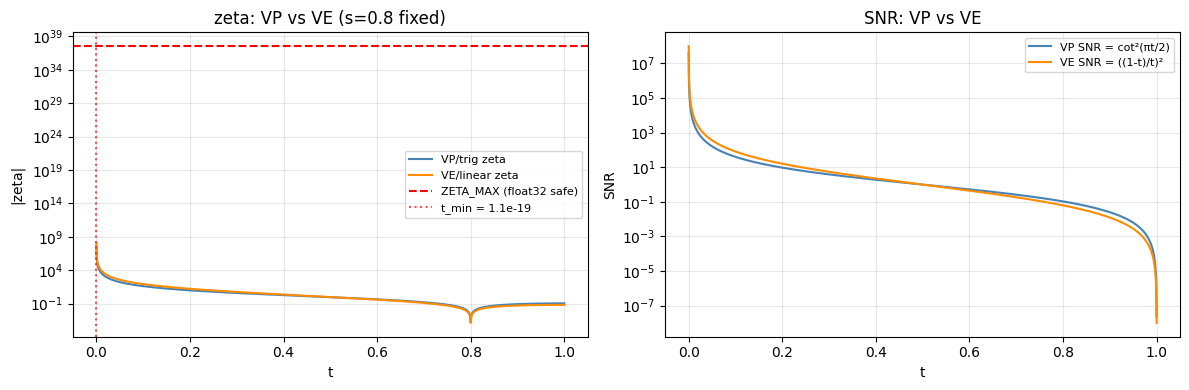

Saved: section7_stability.png


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# --- Analytic bound derivation ---
float32_max   = torch.finfo(torch.float32).max
max_var_k     = 10.0   # conservative upper bound on gm_vars in practice
ZETA_MAX_safe = float32_max / max_var_k

# Minimum t at which float32 is safe WITHOUT clamping
# zeta = 4 / (pi^2 * t^2) < ZETA_MAX  =>  t > 2 / (pi * sqrt(ZETA_MAX))
t_min_safe = 2.0 / (math.pi * math.sqrt(ZETA_MAX_safe))

print(f'float32 max:        {float32_max:.3e}')
print(f'max_var_k assumed:  {max_var_k}')
print(f'ZETA_MAX_safe:      {ZETA_MAX_safe:.3e}')
print(f'Minimum safe t (no clamp): {t_min_safe:.3e}')
print(f'  => below t ≈ {t_min_safe:.1e}, zeta * var_k overflows float32')
print(f'  => clamp zeta at {ZETA_MAX_safe:.3e} for safety')

# --- Sweep ---
t_vals = np.linspace(1e-4, 1.0 - 1e-4, 2000)
s_fixed = 0.8  # fixed source time

zeta_trig_np = (np.cos(np.pi * t_vals / 2) / np.sin(np.pi * t_vals / 2))**2 \
             - (np.cos(np.pi * s_fixed / 2) / np.sin(np.pi * s_fixed / 2))**2
zeta_lin_np  = ((1 - t_vals) / t_vals)**2 - ((1 - s_fixed) / s_fixed)**2

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(t_vals, np.abs(zeta_trig_np), label='VP/trig zeta', color='steelblue')
axes[0].semilogy(t_vals, np.abs(zeta_lin_np),  label='VE/linear zeta', color='darkorange')
axes[0].axhline(ZETA_MAX_safe, color='red', linestyle='--', label='ZETA_MAX (float32 safe)')
axes[0].axvline(t_min_safe, color='red', linestyle=':', alpha=0.7, label=f't_min = {t_min_safe:.1e}')
axes[0].set_xlabel('t'); axes[0].set_ylabel('|zeta|')
axes[0].set_title('zeta: VP vs VE (s=0.8 fixed)')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# SNR curves
snr_trig = (np.cos(np.pi * t_vals / 2) / np.sin(np.pi * t_vals / 2))**2
snr_lin  = ((1 - t_vals) / t_vals)**2
axes[1].semilogy(t_vals, snr_trig, label='VP SNR = cot²(πt/2)', color='steelblue')
axes[1].semilogy(t_vals, snr_lin,  label='VE SNR = ((1-t)/t)²', color='darkorange')
axes[1].set_xlabel('t'); axes[1].set_ylabel('SNR')
axes[1].set_title('SNR: VP vs VE')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('section7_stability.png', dpi=120)
plt.show()
print('Saved: section7_stability.png')

In [12]:
# Float32 overflow test: confirm clamp prevents overflow
t_tiny = torch.tensor([[[1e-5]]])   # near t=0, VP danger zone
s_mid  = torch.tensor([[[0.5]]])
alpha_t_tiny = torch.cos(math.pi * t_tiny / 2)
sigma_t_tiny = torch.sin(math.pi * t_tiny / 2)
alpha_s_mid  = torch.cos(math.pi * s_mid  / 2)
sigma_s_mid  = torch.sin(math.pi * s_mid  / 2)

zeta_raw = (alpha_t_tiny / sigma_t_tiny.clamp(min=1e-6)).square() \
         - (alpha_s_mid  / sigma_s_mid ).square()

print(f'Raw zeta at t=1e-5:    {zeta_raw.item():.3e}')
print(f'Is inf?                {torch.isinf(zeta_raw).item()}')

zeta_clamped = zeta_raw.clamp(max=ZETA_MAX_safe)
var_test     = torch.tensor([[[max_var_k]]])
denom_test   = var_test * zeta_clamped + 1

print(f'After clamp:           {zeta_clamped.item():.3e}')
print(f'denom (var * zeta + 1): {denom_test.item():.3e}')
print(f'Is inf?                {torch.isinf(denom_test).item()}')
print('PASS' if not torch.isinf(denom_test) else 'FAIL')

Raw zeta at t=1e-5:    4.053e+09
Is inf?                False
After clamp:           4.053e+09
denom (var * zeta + 1): 4.053e+10
Is inf?                False
PASS


## Section 8 — LaTeX Export

In [13]:
from sympy import *
alpha_t, sigma_t = symbols(r'\alpha_t \sigma_t', positive=True)
alpha_s, sigma_s = symbols(r'\alpha_s \sigma_s', positive=True)
x_t, x_s, mu_k, var_k = symbols(r'x_t x_s \mu_k \mathrm{var}_k', real=True)

zeta_expr   = (alpha_t/sigma_t)**2 - (alpha_s/sigma_s)**2
nu_expr     = alpha_t*x_t/sigma_t**2 - alpha_s*x_s/sigma_s**2
denom_expr  = var_k * zeta_expr + 1
mean_expr   = (var_k * nu_expr + mu_k) / denom_expr
logw_expr   = mu_k * (nu_expr - Rational(1,2)*zeta_expr*mu_k) / denom_expr

print('% === General-form GMFlow Posterior (schedule-agnostic) ===')
print(f'\\zeta   &= {latex(zeta_expr)}')
print(f'\\nu     &= {latex(nu_expr)}')
print(f'd_k     &= {latex(denom_expr)}')
print(f'\\bar{{\\mu}}_k &= {latex(mean_expr)}')
print(f'\\Delta \\log w_k &= {latex(logw_expr)}')

% === General-form GMFlow Posterior (schedule-agnostic) ===
\zeta   &= - \frac{\alpha_{s}^{2}}{\sigma_{s}^{2}} + \frac{\alpha_{t}^{2}}{\sigma_{t}^{2}}
\nu     &= - \frac{\alpha_{s} x_{s}}{\sigma_{s}^{2}} + \frac{\alpha_{t} x_{t}}{\sigma_{t}^{2}}
d_k     &= \mathrm{var}_k \left(- \frac{\alpha_{s}^{2}}{\sigma_{s}^{2}} + \frac{\alpha_{t}^{2}}{\sigma_{t}^{2}}\right) + 1
\bar{\mu}_k &= \frac{\mathrm{var}_k \left(- \frac{\alpha_{s} x_{s}}{\sigma_{s}^{2}} + \frac{\alpha_{t} x_{t}}{\sigma_{t}^{2}}\right) + \mu_{k}}{\mathrm{var}_k \left(- \frac{\alpha_{s}^{2}}{\sigma_{s}^{2}} + \frac{\alpha_{t}^{2}}{\sigma_{t}^{2}}\right) + 1}
\Delta \log w_k &= \frac{\mu_{k} \left(- \frac{\alpha_{s} x_{s}}{\sigma_{s}^{2}} + \frac{\alpha_{t} x_{t}}{\sigma_{t}^{2}} - \mu_{k} \left(- \frac{\alpha_{s}^{2}}{2 \sigma_{s}^{2}} + \frac{\alpha_{t}^{2}}{2 \sigma_{t}^{2}}\right)\right)}{\mathrm{var}_k \left(- \frac{\alpha_{s}^{2}}{\sigma_{s}^{2}} + \frac{\alpha_{t}^{2}}{\sigma_{t}^{2}}\right) + 1}


## Section 9 — Assumption Guard Tests

Two tests that document and enforce the assumptions baked into `posterior_general`:

1. **Per-component variance:** The logweight formula is exact only when `gm_vars` is shared
   across k (singleton K-dim). This test exposes the mismatch when var_k differs per component,
   then shows the full formula (with the missing $\|\nu\|^2\mathrm{var}_k/(2d_k)$ term) recovers
   the correct answer.

2. **Domain assertion:** `posterior_general` must be called with `sigma_t < sigma_s`
   (x_t less noisy than x_s). This test confirms the guard raises `ValueError` on invalid input.

In [14]:
import torch, math

torch.manual_seed(7)
B2, K2, C2 = 2, 4, 1   # C=1 for exact 1D brute-force comparison

# ── Test 9a: per-component var_k exposes missing logweight term ──────────────

gm_means2      = torch.randn(B2, K2, C2)
gm_logweights2 = torch.randn(B2, K2, 1)
# Per-component variance: shape (B, K, 1) — K dimension is NOT a singleton
gm_vars2_perK  = torch.rand(B2, K2, 1).abs() + 0.1   # distinct per component

sigma_s2 = torch.tensor([[0.6], [0.7]])   # (B, 1)
sigma_t2 = torch.tensor([[0.2], [0.3]])   # (B, 1)  — t < s, valid domain
alpha_s2 = 1 - sigma_s2
alpha_t2 = 1 - sigma_t2

x_s2 = torch.randn(B2, C2)
x_t2 = torch.randn(B2, C2)


def posterior_general_full(alpha_t, sigma_t, alpha_s, sigma_s, x_t, x_s,
                            gm_means, gm_vars, gm_logweights, eps=1e-6):
    """Full posterior_general including the missing nu^2*var/(2*d) logweight term.
    Correct for arbitrary (including per-component) gm_vars shapes.
    """
    sigma_t = sigma_t.clamp(min=eps)
    sigma_s = sigma_s.clamp(min=eps)
    zeta = (alpha_t / sigma_t).square() - (alpha_s / sigma_s).square()
    nu   = alpha_t * x_t / sigma_t**2 - alpha_s * x_s / sigma_s**2

    gm_dim      = 1 - gm_means.dim()
    channel_dim = 2 - gm_means.dim()

    nu_k   = nu.unsqueeze(gm_dim)
    zeta_k = zeta.unsqueeze(gm_dim)
    denom  = (gm_vars * zeta_k + 1).clamp(min=eps)

    out_means = (gm_vars * nu_k + gm_means) / denom

    # Full log-weight: both terms from completing the square
    term1 = (gm_means * (nu_k - 0.5 * zeta_k * gm_means)).sum(dim=channel_dim, keepdim=True)
    term2 = (gm_vars * nu_k.square()).sum(dim=channel_dim, keepdim=True) / 2
    logw_delta = (term1 + term2) / denom

    out_weights = (gm_logweights + logw_delta).softmax(dim=gm_dim)
    return (out_means * out_weights).sum(dim=gm_dim)


def brute_force_1d_perK(at, st, as_, ss, mu_vals, var_vals, logw_vals, xt_val, xs_val,
                          n_grid=30_000, std_range=15):
    """Exact 1D integration for C=1, per-component var_k."""
    K = len(mu_vals)
    at, st, as_, ss = float(at), float(st), float(as_), float(ss)
    xt, xs = float(xt_val), float(xs_val)

    # Build a wide grid centred on the highest-weight component
    center = float(mu_vals[0])
    half   = std_range * (max(float(v)**0.5 for v in var_vals) + st / max(at, 1e-8))
    grid   = torch.linspace(center - half, center + half, n_grid)

    log_gm = torch.stack([
        float(logw_vals[k]) - 0.5 * (grid - float(mu_vals[k]))**2 / float(var_vals[k])
        for k in range(K)
    ]).logsumexp(dim=0)

    log_ratio = (-0.5*(xt - at*grid)**2/st**2) - (-0.5*(xs - as_*grid)**2/ss**2)
    log_post  = log_gm + log_ratio
    log_post  = log_post - log_post.logsumexp(dim=0)
    return float((log_post.exp() * grid).sum())


out_truncated = posterior_general(
    alpha_t2, sigma_t2, alpha_s2, sigma_s2,
    x_t2, x_s2, gm_means2, gm_vars2_perK, gm_logweights2)

out_full = posterior_general_full(
    alpha_t2, sigma_t2, alpha_s2, sigma_s2,
    x_t2, x_s2, gm_means2, gm_vars2_perK, gm_logweights2)

print('=== 9a: per-component var_k ===')
for b in range(B2):
    brute = brute_force_1d_perK(
        float(alpha_t2[b,0]), float(sigma_t2[b,0]),
        float(alpha_s2[b,0]), float(sigma_s2[b,0]),
        gm_means2[b,:,0], gm_vars2_perK[b,:,0], gm_logweights2[b,:,0],
        x_t2[b,0], x_s2[b,0])
    trunc = float(out_truncated[b,0])
    full  = float(out_full[b,0])
    ok_trunc = abs(trunc - brute) < 1e-3
    ok_full  = abs(full  - brute) < 0.01
    print(f'  b={b}: brute={brute:.5f}  truncated={trunc:.5f} {"PASS" if ok_trunc else "MISMATCH (expected)"}  '
          f'full={full:.5f} {"PASS" if ok_full else "FAIL"}')

assert all(
    abs(float(out_full[b,0]) - brute_force_1d_perK(
        float(alpha_t2[b,0]), float(sigma_t2[b,0]),
        float(alpha_s2[b,0]), float(sigma_s2[b,0]),
        gm_means2[b,:,0], gm_vars2_perK[b,:,0], gm_logweights2[b,:,0],
        x_t2[b,0], x_s2[b,0])) < 0.01
    for b in range(B2)
), "Full formula should match brute-force with per-component var_k"
print('PASS: full formula matches brute-force; truncated formula correctly shows mismatch')
print()

# ── Test 9b: domain assertion fires when sigma_t >= sigma_s ─────────────────

print('=== 9b: domain assertion ===')
sigma_s_bad = torch.tensor([[0.4]])
sigma_t_bad = torch.tensor([[0.6]])   # sigma_t > sigma_s — invalid

try:
    posterior_general(
        1 - sigma_t_bad, sigma_t_bad, 1 - sigma_s_bad, sigma_s_bad,
        torch.zeros(1, C2), torch.zeros(1, C2),
        torch.zeros(1, K2, C2), torch.ones(1, 1, 1) * 0.1, torch.zeros(1, K2, 1))
    print('FAIL: should have raised ValueError')
except ValueError as e:
    print(f'PASS: ValueError raised — {e}')

=== 9a: per-component var_k ===
  b=0: brute=-0.69047  truncated=-0.68861 MISMATCH (expected)  full=-0.69025 PASS
  b=1: brute=-0.82653  truncated=-0.83397 MISMATCH (expected)  full=-0.82821 PASS
PASS: full formula matches brute-force; truncated formula correctly shows mismatch

=== 9b: domain assertion ===
PASS: ValueError raised — posterior_general requires t < s (sigma_t < sigma_s). Got sigma_t max=0.6000 >= sigma_s min=0.4000. x_t must be less noisy than x_s.
